### First run the main notebook

In [3]:
%%capture
%run ./Image_processing_fundamentals_pt3.ipynb

(27, 1024, 1024) (27, 1024, 1024)


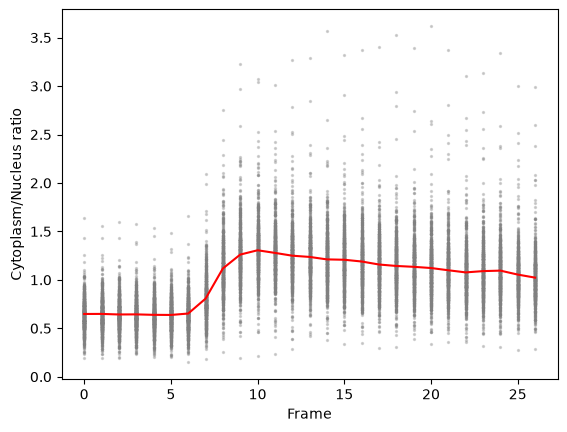

In [4]:
# Answer: Batch analysis of the KTR data

# Location of the unzipped data, and number of frames (files per folder)
data_folder = "/Users/m.wehrens/Data_notbacked/2025_Py-Image-workshop_KTR-example-data/KTR-images-series/"
nr_frames = 27

# Load all frames into one big array (dimensions: time, y, x)
list_nuclei = []
list_KTR = []
for t in range(nr_frames):
    # file numbers are padded with zeros to 4 digits, e.g. 0001
    img_nuclei = tiff.imread(data_folder + "nuclei/KTR_nuclei_frame_" + str(t).zfill(4) + ".tif")
    img_KTR    = tiff.imread(data_folder + "sensor/KTR_sensor_frame_" + str(t).zfill(4) + ".tif")
    list_nuclei.append(img_nuclei)
    list_KTR.append(img_KTR)
all_nuclei = np.array(list_nuclei)
all_KTR = np.array(list_KTR)
print(all_nuclei.shape, all_KTR.shape)

# Function that calculates the C/N ratios of a single frame
def calculate_KTR_ratios(img_nuclei, img_KTR):

    # Nuclei mask using triangle method
    thresh_triangle = sk.filters.threshold_triangle(img_nuclei)
    mask_nuclei = img_nuclei > thresh_triangle
    mask_nuclei_clean = sk.morphology.opening(mask_nuclei, footprint=sk.morphology.disk(3))

    # Background subtraction using the mode
    the_mode = stats.mode(img_KTR.ravel())[0]
    img_KTR_corr = img_KTR - the_mode
    img_KTR_corr[img_KTR < the_mode] = 0

    # Labeled nuclei, and labeled rings around them (cytoplasm)
    mask_nuclei_labeled = sk.measure.label(mask_nuclei_clean, connectivity=1)
    mask_cytoplasm_labeled = sk.morphology.dilation(mask_nuclei_labeled, sk.morphology.disk(2))
    mask_cytoplasm_labeled[mask_nuclei_clean] = 0

    # Mean intensities per region, and C/N ratios
    rprops_KTR_nuclei = sk.measure.regionprops(mask_nuclei_labeled, intensity_image=img_KTR_corr)
    rprops_KTR_cyto = sk.measure.regionprops(mask_cytoplasm_labeled, intensity_image=img_KTR_corr)
    KTR_ratios = [c.intensity_mean / n.intensity_mean for c, n in zip(rprops_KTR_cyto, rprops_KTR_nuclei)]

    return KTR_ratios

# Apply the function to all time points
all_ratios = []
for t in range(nr_frames):
    ratios = calculate_KTR_ratios(all_nuclei[t], all_KTR[t])
    all_ratios.append(ratios)

# Plot all ratios per time point, and the mean ratio over time
for t in range(nr_frames):
    # x-values: the time point, repeated for each cell
    _ = plt.scatter([t]*len(all_ratios[t]), all_ratios[t], color="gray", s=2, alpha=0.3)
_ = plt.plot([np.mean(r) for r in all_ratios], color="r")
_ = plt.xlabel("Frame")
_ = plt.ylabel("Cytoplasm/Nucleus ratio")


In [5]:
# Or add the data to a pandas dataframe
df_data_ratios = pd.DataFrame({"frame": [], "ratio": []})
for fr_idx in range(nr_frames):
    df_data_ratios = pd.concat(\
        [
        df_data_ratios, 
        pd.DataFrame({
            "frame": [fr_idx]*len(all_ratios[fr_idx]), 
            "ratio": all_ratios[fr_idx]
            })
        ], 
        ignore_index=True
        )

# Add time
df_data_ratios["time_min"] = df_data_ratios["frame"] * 270.01617/60

# Show the dataframe    
df_data_ratios.head()    

,frame,ratio,time_min
0,0.0,0.569553,0.0
1,0.0,0.769978,0.0
2,0.0,0.571828,0.0
3,0.0,0.591544,0.0
4,0.0,0.725239,0.0


Text(0, 0.5, 'C/N Ratio')

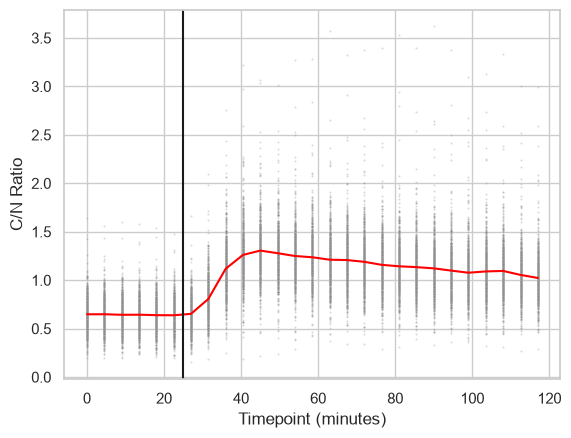

In [13]:
# And plot the data using seaborn
sns.set_theme(style="whitegrid")
sns.scatterplot(df_data_ratios, 
                x="time_min", y="ratio", 
                color="gray", s=2, alpha=0.3)
sns.lineplot(df_data_ratios, 
                x="time_min", y="ratio", 
                color="red", errorbar=None)
plt.axvline(25, color="k")
# Set axis labels
plt.xlabel("Timepoint (minutes)")
plt.ylabel("C/N Ratio")